# State Schema

In this notebook, we are going to build a deeper understanding of both state and memory.

First, let's review a few different ways to define our state schema.

## Schema

When we define a LangGraph `StateGraph`, use a state schema.

The state schema represents the structure and types of data that our graph will use.

All nodes are expected to communicate with that schema.

### TypedDict

In [1]:
from typing import TypedDict

class TypedDictState(TypedDict):
    abc: str
    xyz: str

For more specific value constraints, we can use things like `Literal` type hint.

Here, `mood` can only be either "happy" or "sad".

In [2]:
from typing import Literal

class TypedDictState(TypedDict):
    name: str
    mood: Literal["happy", "very happy"]

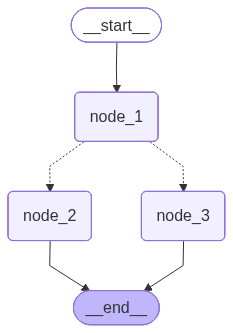

In [3]:
# let's build a simple graph using typeddict state
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

def node_1(state):
    print("---Node 1---")
    return {"name": state['name'] + ' is ... '}

def node_2(state):
    print("---Node 2---")
    return {"mood": "happy"}

def node_3(state):
    print("---Node 3---")
    return {"mood": "sad"}


def decide_mood(state) -> Literal["node_2", "node_3"]:
    if random.random() < 0.5:
        return "node_2"
    return "node_3"


# build graph
builder = StateGraph(TypedDictState)

# nodes
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# edges
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)


# add
graph = builder.compile()

# view
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
graph.invoke({"name": "saket"})

---Node 1---
---Node 2---


{'name': 'saket is ... ', 'mood': 'happy'}

### Dataclasses

In [5]:
from dataclasses import dataclass

@dataclass
class DataclassState:
    name: str
    mood: Literal["happy", "very happy"]

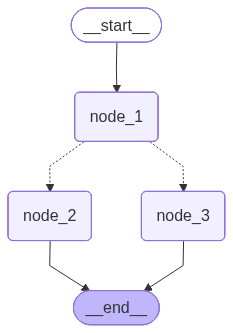

In [6]:
def node_1(state):
    print("---Node 1---")
    return {"name": state.name + " is ..."}


# bUild graph
builder = StateGraph(DataclassState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# add
graph = builder.compile()


# view
display(Image(graph.get_graph().draw_mermaid_png()))


In [7]:
graph.invoke(DataclassState(name="Saket", mood="happy"))

---Node 1---
---Node 3---


{'name': 'Saket is ...', 'mood': 'sad'}

### Pydantic

As mentioned, `TypedDict` and `dataclasses` provide type hints but they don't enforce types at runtime.

This means you could potentially assign invalide values without raising an error.

In [8]:
dataclass_instance = DataclassState(name="Saket", mood="super")

Pydantic is a data validation and settings management library using Python type annotations.

In [9]:
from pydantic import BaseModel, field_validator, ValidationError

class PydanticState(BaseModel):
    name: str
    mood: str

    @field_validator('mood')
    @classmethod
    def validate_mood(cls, value):
        if value not in ["happy", "very happy"]:
            raise ValueError("Each mood must be either Happy or Very happy")
        return value
    
try:
    state = PydanticState(name="Saket", mood="mad")
except ValidationError as e:
    print("Validation error:", e)

Validation error: 1 validation error for PydanticState
mood
  Value error, Each mood must be either Happy or Very happy [type=value_error, input_value='mad', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error


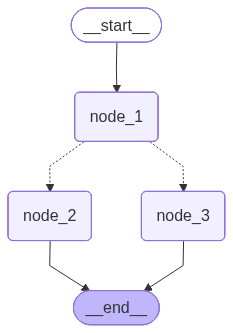

In [10]:
# use in graph
builder = StateGraph(PydanticState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)


# logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)


# add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
graph.invoke(PydanticState(name="Saket", mood="happy"))

---Node 1---
---Node 3---


{'name': 'Saket is ...', 'mood': 'sad'}

# State Reducers

We're going to dive into reducers, which specify how state updates are performed on specific keys / channels in the state schema.

## Default overwriting state

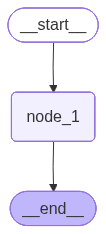

In [12]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    abc: int

def node_1(state):
    print("---Node 1---")
    return {"abc": state['abc'] + 1}

# build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# add
graph = builder.compile()

# view
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
graph.invoke({"abc": 1})

---Node 1---


{'abc': 2}

## Branching

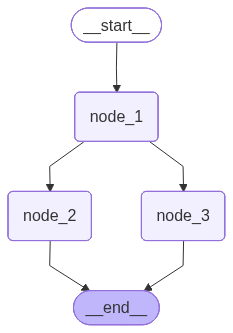

In [14]:
def node_2(state):
    print("---Node 2---")
    return {"abc": state["abc"] + 1}

def node_3(state):
    print("---Node 3---")
    return {"abc": state["abc"] + 1}

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# add
graph = builder.compile()


# view
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"abc": 1})
except InvalidUpdateError as e:
    print(f"InvalidUpdateError occured: {e}")

---Node 1---
---Node 2---
---Node 3---
InvalidUpdateError occured: At key 'abc': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


We see a problem!

Node 1 branches to nodes 2 and 3

Nodes 2 and 3 run in parallel, which means they run in the same step of the graph.

## Reducers

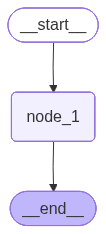

In [16]:
from operator import add
from typing import Annotated

class State(TypedDict):
    abc: Annotated[list[int], add]

def node_1(state):
    print("---Node 1---")
    return {"abc": [state["abc"][0] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# add
graph = builder.compile()

# view
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
graph.invoke({"abc": [1]})

---Node 1---


{'abc': [1, 2]}

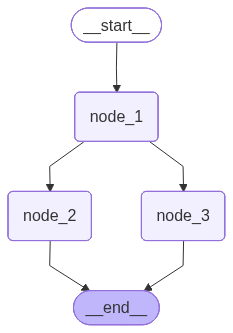

In [18]:
def node_1(state):
    print("---Node 1---")
    return {"abc": [state['abc'][-1] + 1]}

def node_2(state):
    print("---Node 2---")
    return {"abc": [state['abc'][-1] + 1]}

def node_3(state):
    print("---Node 3---")
    return {"abc": [state['abc'][-1] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
graph.invoke({"abc": [1]})

---Node 1---
---Node 2---
---Node 3---


{'abc': [1, 2, 3, 3]}

In [20]:
try:
    graph.invoke({"abc": None})
except TypeError as e:
    print(f"TypeError occured: {e}")

TypeError occured: can only concatenate list (not "NoneType") to list


## Custom Reducers

In [21]:
def reduce_list(left: list | None, right: list | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None) : The first list to combine, or None
        right (list | None) : The second list to combine, or None

    Returns:
        list: A new list containing all elements from both input lists.
                If an input is None, it's treated as an empty list.
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class DefaultState(TypedDict):
    abc : Annotated[list[int], add]

class CustomReducerState(TypedDict):
    abc : Annotated[list[int], reduce_list] 


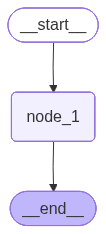

TypeError occured: can only concatenate list (not "NoneType") to list


In [22]:
def node_1(state):
    print("---Node 1---")
    return {"abc": [2]}

# build graph
builder = StateGraph(DefaultState)
builder.add_node("node_1", node_1)

# logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# compile
graph = builder.compile()

# display
display(Image(graph.get_graph().draw_mermaid_png()))

try:
    print(graph.invoke({"abc": None}))
except TypeError as e:
    print(f"TypeError occured: {e}")

In [23]:
builder = StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)


builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

graph = builder.compile()

try:
    print(graph.invoke({"abc": None}))
except TypeError as e:
    print(f"TypeError occured: {e}")


---Node 1---
{'abc': [2]}


# Messages

In [24]:
from typing import Annotated
from langgraph.graph import MessagesState
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# Define a custom TypedDict that includes a list of messages with add_messages reducer
class CustomMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    added_key_1: str
    added_key_2: str
    # etc

# Use MessagesState, which includes the messages key with add_messages reducer
class ExtendedMessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built
    added_key_1: str
    added_key_2: str
    # etc

In [25]:
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage

# Initial state
initial_messages = [
                        AIMessage(content="Hello! How can I assist you?", name="Model"),
                        HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                    ]


# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")


# Test
add_messages(initial_messages, new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='6d8ebd4b-847e-4d96-af90-f8bf1b682e78', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='f7ffefa7-8117-4e77-8158-29dc6a24ed81'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='bfc47262-b10b-43eb-a84d-65aadf137987', tool_calls=[], invalid_tool_calls=[])]

## Removal

In [26]:
from langchain_core.messages import RemoveMessage

# Message list
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Isolate messages to delete
delete_messages = [RemoveMessage(id=m.id) for m in messages[:-2]]
print(delete_messages)

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2')]


In [27]:
add_messages(messages, delete_messages)

[AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about whales. But what others should I learn about?', additional_kwargs={}, response_metadata={}, name='Lance', id='4')]

# Multiple Schemas

## Private State

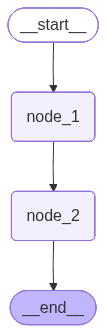

In [28]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class OverallState(TypedDict):
    abc: int

class PrivateState(TypedDict):
    xyz: int

def node_1(state: OverallState) -> PrivateState:
    print("---Node 1---")
    return {"xyz" : state['abc'] + 1}

def node_2(state: PrivateState) -> OverallState:
    print("--Node 2---")
    return {"abc" : state['xyz'] + 1}

# Build graph
builder = StateGraph(OverallState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# compile
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))




In [29]:
graph.invoke({"abc": 1})

---Node 1---
--Node 2---


{'abc': 3}

## Input / Output Schema

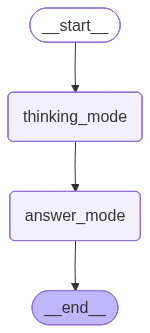

In [30]:
class OverallState(TypedDict):
    question: str
    answer: str
    notes: str


def thinking_mode(state: OverallState):
    return {"answer": "bye", "notes": "... his name is Saket"}

def answer_mode(state: OverallState):
    return {"answer": "bye Saket"}


graph = StateGraph(OverallState)
graph.add_node("answer_mode", answer_mode)
graph.add_node("thinking_mode", thinking_mode)
graph.add_edge(START, "thinking_mode")
graph.add_edge("thinking_mode", "answer_mode")
graph.add_edge("answer_mode", END)

graph = graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
graph.invoke({"question": "hi"})

{'question': 'hi', 'answer': 'bye Saket', 'notes': '... his name is Saket'}